In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/train.csv')

df.shape        


Matplotlib is building the font cache; this may take a moment.


(891, 12)

In [2]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)
print('Пропусков в %:')
print(missing_pct[missing_pct > 0])


Пропусков в %:
Cabin       77.104377
Age         19.865320
Embarked     0.224467
dtype: float64


In [10]:
df['Survived'].value_counts(normalize=True)
# 0 (погиб)    61.6%
# 1 (выжил)    38.4%

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

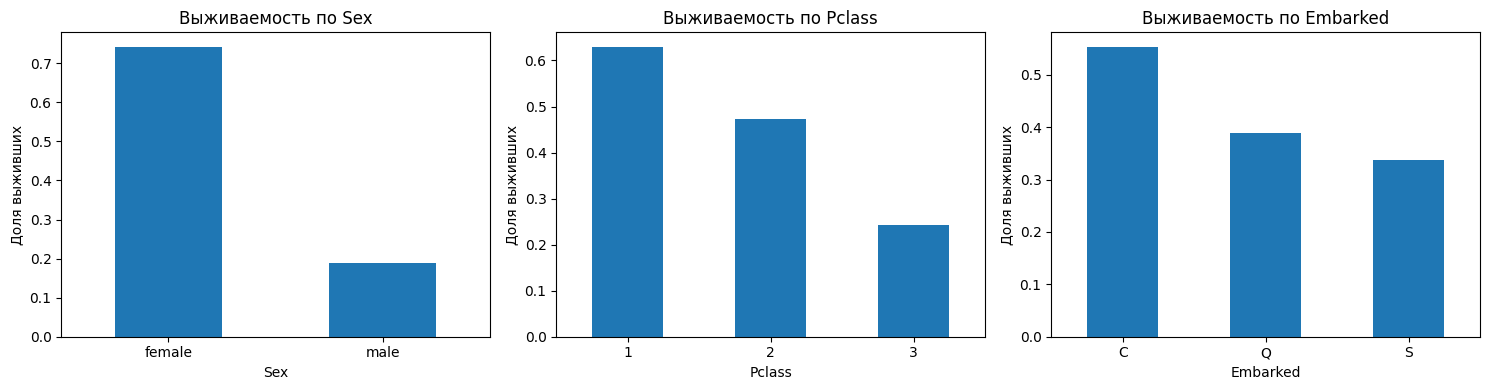

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Sex', 'Pclass', 'Embarked']):
    df.groupby(col)['Survived'].mean().plot(kind='bar', ax=ax)
    ax.set_title(f'Выживаемость по {col}')
    ax.set_ylabel('Доля выживших')
    ax.tick_params(rotation=0)

plt.tight_layout()
plt.show()

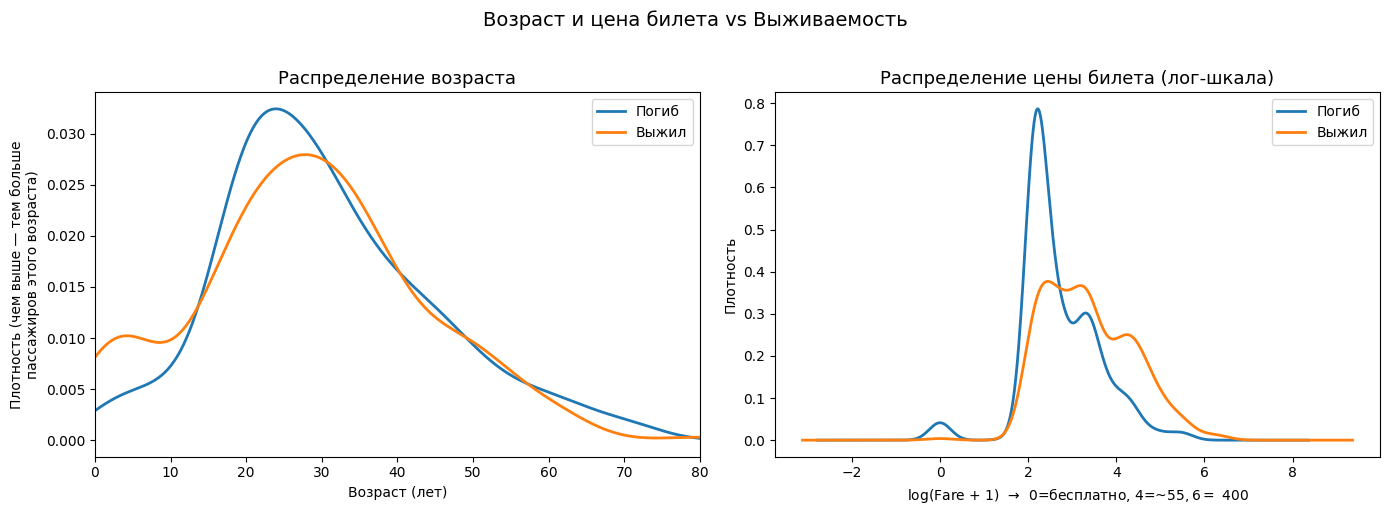

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Возраст ---
for survived, group in df.groupby('Survived')['Age']:
    group.dropna().plot(
        kind='kde',
        ax=axes[0],
        label='Выжил' if survived else 'Погиб',
        linewidth=2
    )

axes[0].set_title('Распределение возраста', fontsize=13)
axes[0].set_xlabel('Возраст (лет)')
axes[0].set_ylabel('Плотность (чем выше — тем больше\nпассажиров этого возраста)')
axes[0].legend()
axes[0].set_xlim(0, 80)  # убираем хвосты за пределами реальных значений

# --- График 2: Цена билета (лог-шкала) ---
import numpy as np

for survived, group in df.groupby('Survived')['Fare']:
    np.log1p(group).plot(  # логарифм убирает влияние выбросов
        kind='kde',
        ax=axes[1],
        label='Выжил' if survived else 'Погиб',
        linewidth=2
    )

axes[1].set_title('Распределение цены билета (лог-шкала)', fontsize=13)
axes[1].set_xlabel('log(Fare + 1)  →  0=бесплатно, 4=~55$, 6=~400$')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.suptitle('Возраст и цена билета vs Выживаемость', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Выживаемость: пол × класс')

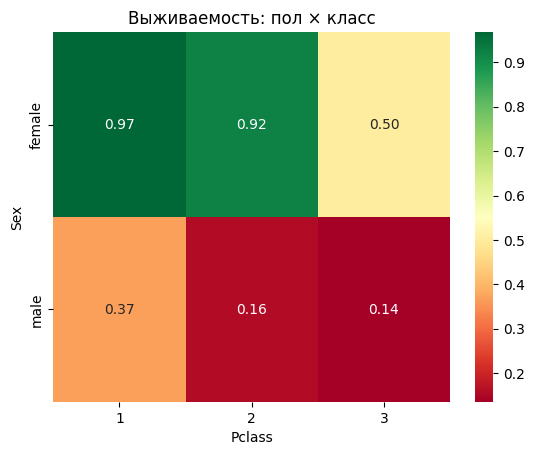

In [13]:
# Выживаемость: пол + класс вместе
pivot = df.pivot_table('Survived',
                        index='Sex',
                        columns='Pclass',
                        aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Выживаемость: пол × класс')

Text(0.5, 1.0, 'Корреляционная матрица')

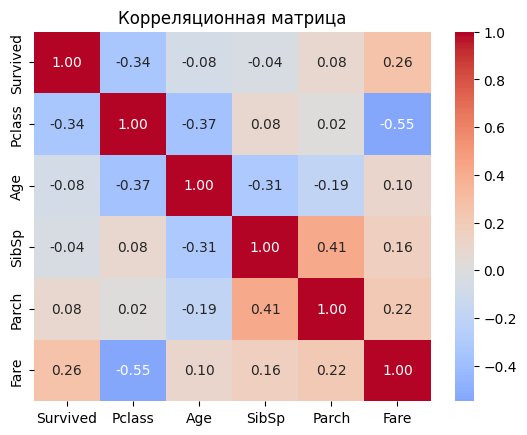

In [14]:
# Только числовые столбцы
corr = df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')

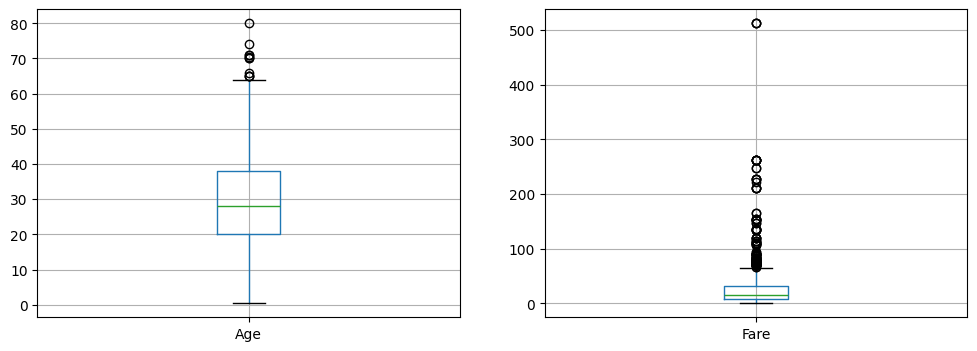

,Name,Fare,Pclass,Survived
258,"Ward, Miss. Anna",512.3292,1,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1,1
737,"Lesurer, Mr. Gustave J",512.3292,1,1


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column='Age', ax=axes[0])
df.boxplot(column='Fare', ax=axes[1])
plt.show()

# Самые дорогие билеты
df[df['Fare'] > 300][['Name','Fare','Pclass','Survived']]

Ключевые инсайты по Титанику:

1) Самые сильные предикторы выживания — пол (женщина/мужчина), класс билета, цена билета. Эти три признака объясняют большую часть выживаемости.
2) Дети выживали лучше — возраст до 10 лет значимо повышал шансы.
3) Одиночки выживали хуже семейных пар и маленьких семей.
4) Порт посадки — прокси социального статуса — пассажиры из Cherbourg в среднем богаче, поэтому выживали чаще.
5) Cabin — почти бесполезен напрямую, но флаг "есть каюта / нет каюты" информативен: наличие каюты означало более высокий класс.